# Analysis of Electoral College Votes in the United States

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

### Import Data

- Electoral college data: includes all primary voting years
- Population data: 2020 census (current usage for determining electoral votes)

In the United States, the electoral college is used to elect the President of the United States. Senators and representatives from each state cast their 'electoral vote', which is primarly based on the popular vote of their state. Two states, Maine and Nebraska, split their votes for the winner of each district (more closely resembling a popular vote). Each state has two senators and at least one representative. The number of representatives increases as population increases, but is not set by a specific value. For instance, the state of Wyoming has a population of 576,851. There are three electors: two senators and one representative. Each elector represents approximately 192,283 people. In contrast, the population of Texas is 29,145,505 and has 40 electoral votes (2 senators and 38 representatives). Each elector represents approximately 728,637 people. That is over half a million more people each elector represents than is represented in Wyoming. The following analysis will highlight the imbalance of voting power and some possible solutions if the electoral college continued to be the way presidents are voted into office.

In [2]:
electoral_data = pd.read_csv("data/electoral_data.csv")

# focus on 2024 election cycle (electoral college will be the same for 2028 due to the 2020 census)
electoral_24 = electoral_data[["State", "[2024, 2028]"]]

# change value for Washington DC for consistency between tables
electoral_24.replace("D.C.", "DC", inplace=True)
electoral_24.head()

,State,"[2024, 2028]"
0,Alabama,9
1,Alaska,3
2,Arizona,11
3,Arkansas,6
4,California,54
5,Colorado,10
6,Connecticut,7
7,DC,3
8,Delaware,3
9,Florida,30


In [3]:
pop_data = pd.read_csv("data/census_data.csv")

# table with only population of each state from 2020 census
state_pop = pop_data[["state", "2020_census"]]
state_pop.head()

,state,2020_census
0,California,39538223
1,Texas,29145505
2,Florida,21538187
3,New York,20201249
4,Pennsylvania,13002700
5,Illinois,12812508
6,Ohio,11799448
7,Georgia,10711908
8,North Carolina,10439388
9,Michigan,10077331


### Visualization of the population of each state

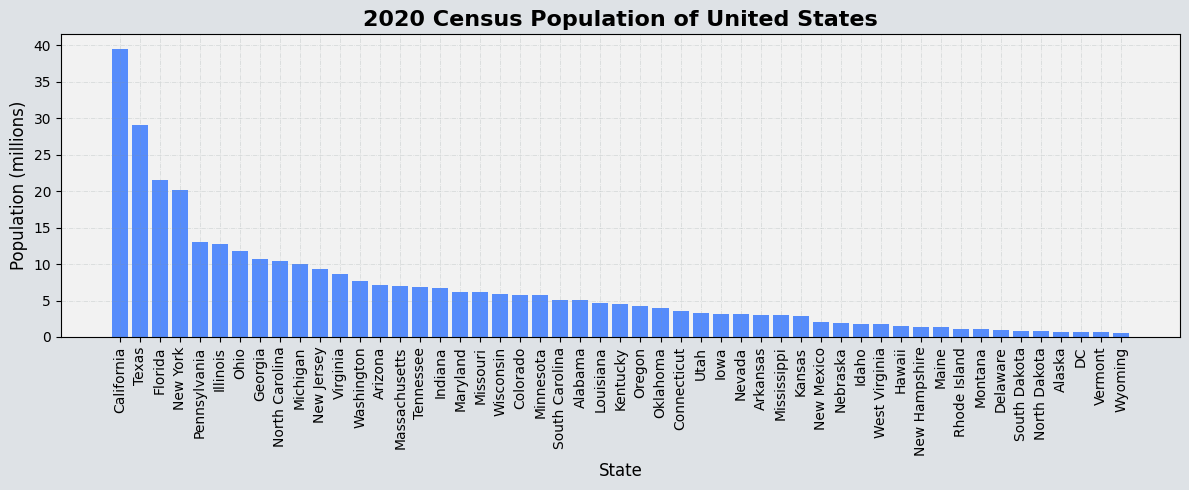

In [4]:
# Visualization of state population

# define variables for axes
x = pop_data["state"]
y = pop_data["2020_census"] / 1000000 # simplifies the y-axis range of values

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

plt.ticklabel_format(axis='y', style='plain')
plt.bar(x, y)

ax.set_xticks(range(51))
ax.set_xticklabels(x, rotation=90, ha="center")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Population (millions)", fontsize=12)
ax.set_title("2020 Census Population of United States", fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

plt.tight_layout()
plt.show()

# 2024 Electoral College

### Visualization of Electoral College Votes by State

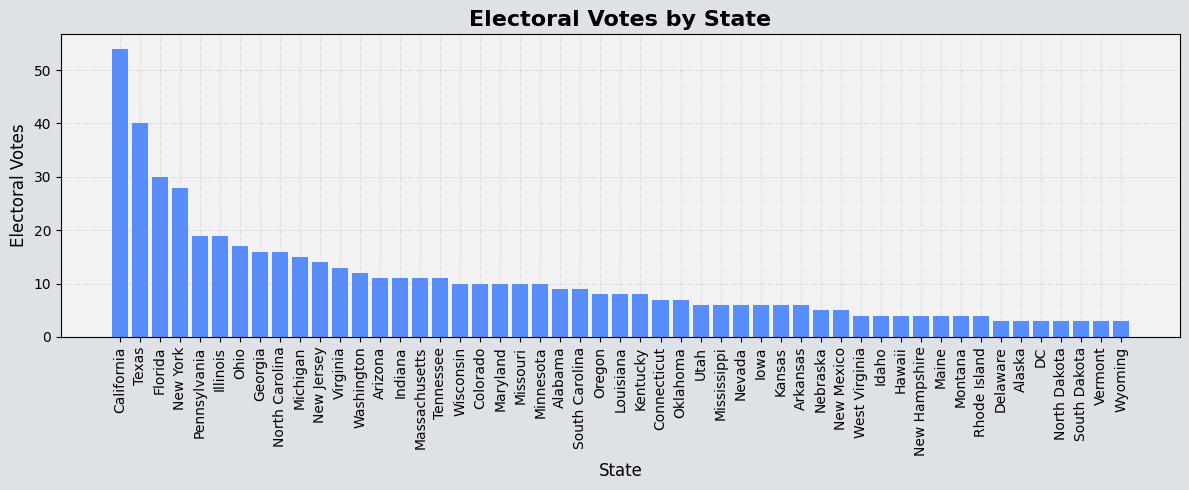

In [5]:
# visualization of electoral votes by state

# sort values for visually appealing graph
electoral_24_sorted = electoral_24.sort_values(by="[2024, 2028]", ascending=False)

# define variables for axes
x = electoral_24_sorted["State"]
y = electoral_24_sorted["[2024, 2028]"]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

plt.ticklabel_format(axis='y', style='plain')
plt.bar(x, y)

ax.set_xticks(range(51))
ax.set_xticklabels(x, rotation=90, ha="center")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Electoral Votes", fontsize=12)
ax.set_title("Electoral Votes by State", fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

plt.tight_layout()
plt.show()

## Merge population and electoral college tables for analysis

In [6]:
# merge tables to match electoral votes with the state population
elector_population = pd.merge(electoral_24, state_pop, left_on="State", right_on="state")

# keep one column of state names
elector_population = elector_population.drop(columns=["state"])

# rename the voting year to electoral_votes
elector_population = elector_population.rename(columns={"[2024, 2028]":"electoral_votes"})

# create a column to show how much of the population is represented by each electoral vote
elector_population["pop_per_elector"] = round(elector_population["2020_census"] / elector_population["electoral_votes"], 2)

elector_population.head()

,State,electoral_votes,2020_census,pop_per_elector
0,Alabama,9,5024279,558253.22
1,Alaska,3,733391,244463.67
2,Arizona,11,7151502,650136.55
3,Arkansas,6,3011524,501920.67
4,California,54,39538223,732189.31
5,Colorado,10,5773714,577371.40
6,Connecticut,7,3605944,515134.86
7,DC,3,689545,229848.33
8,Delaware,3,989948,329982.67
9,Florida,30,21538187,717939.57


## Analysis of Basic Statistics of Electoral College Votes

In [7]:
# find the mean, median of electoral votes in current system
median_pop_elector = elector_population["pop_per_elector"].median()
mean_pop_elector = round(elector_population["pop_per_elector"].mean(), 2)

# calculate the difference between these two numbers
elector_diff = median_pop_elector - mean_pop_elector

print("Number of people represented by an elector:")
print(f"Median: {median_pop_elector}")
print(f"Mean: {mean_pop_elector}", )
print(f"Difference: {elector_diff}")

Number of people represented by an elector:
Median: 563229.5
Mean: 518981.92
Difference: 44247.580000000016


Because there are fewer people represented for the mean calculation, the overall distribution means there are more areas where there are fewer people being represented by each elector. The median is more robust to outliers (very high or very low values), and since the median is higher by over 44,000 people, that means there are some areas that have a much higher density of representation (more people per elector). Further analysis will show this more clearly, and point to the areas where there is a disparity in electoral representation.

In [8]:
# calculate the total population by total number of electoral votes (not just voting age individuals)
total_pop = elector_population["2020_census"].sum()
total_votes = elector_population["electoral_votes"].sum()

# divide the total population of the US by the total number of electoral votes
total_pop_elector = round(total_pop / total_votes, 2)
print(f"Total population of the U.S.: {total_pop}.")
print(f"The total number of electoral college votes: {total_votes}.")
print(f"Each electoral vote should represent {total_pop_elector} people.")

Total population of the U.S.: 331449281.
The total number of electoral college votes: 538.
Each electoral vote should represent 616076.73 people.


In [9]:
# find the minimum and maximum number of people represented by electors
max_pop_elector = elector_population["pop_per_elector"].max()
min_pop_elector = elector_population["pop_per_elector"].min()
elector_diff_MinMax = max_pop_elector - min_pop_elector

print("The number of people being represented by one elector:")
print(f"Maximum : {max_pop_elector}")
print(f"Winimum: {min_pop_elector}")
print(f"Difference: {elector_diff_MinMax}")

The number of people being represented by one elector:
Maximum : 732189.31
Winimum: 192283.67
Difference: 539905.64


These numbers show that in one area, there are only 192,283 people represented by one elector (the minimum). The maximum number is 732,189, which is well over half a million more people represented by one elector than the minimum. A basic analysis of the mean and median also show there is a disparity of the voting power in different regions of the United States.

## Proportion of Electoral Votes by State

In [10]:
# voting power is determined by calculating the number of people who should be represented per electoral vote divided by the actual number of each electoral vote of each state
elector_population["proportion_vote"] = total_pop_elector / elector_population["pop_per_elector"]
# elector_population

The numbers here show the voting power of one individual electoral vote. The closer the number is to 1, the more voting power there is based on an equitable distribution of votes  (one vote equals one vote). The lower the proportion, the less voting power (.7 is 70% of one vote). The higher the proportion, the more voting power (2.25 is more than twice one vote).

For the sake of this analysis, let's say we decided to keep the electoral college with same number of electoral votes (538). However, we choose to distribute the current number of votes based on population, rather than the current system. This means we can analyze how the voting power would change. This would create a system in which each electoral college vote would represent an equal number of people. (This would not be akin to using the popular vote, since winner takes all.) To achieve an equal distribution of votes, we will use the population percentage of each state to determine electoral college votes assigned to it.

In [11]:
# create a column in the population data table to show what the electoral votes should be based on for equal distribution

pop_data["elect_votes_by_percent"] = round(pop_data["percent_of_total"] * total_votes, 0)
pop_data.head()

,Unnamed: 0,rank,state,state_code,2020_census,percent_of_total,elect_votes_by_percent
0,0,1,California,CA,39538223,0.1193,64.0
1,1,2,Texas,TX,29145505,0.0879,47.0
2,2,3,Florida,FL,21538187,0.0650,35.0
3,3,4,New York,NY,20201249,0.0609,33.0
4,4,5,Pennsylvania,PA,13002700,0.0392,21.0
5,5,6,Illinois,IL,12812508,0.0387,21.0
6,6,7,Ohio,OH,11799448,0.0356,19.0
7,7,8,Georgia,GA,10711908,0.0323,17.0
8,8,9,North Carolina,NC,10439388,0.0315,17.0
9,9,10,Michigan,MI,10077331,0.0304,16.0


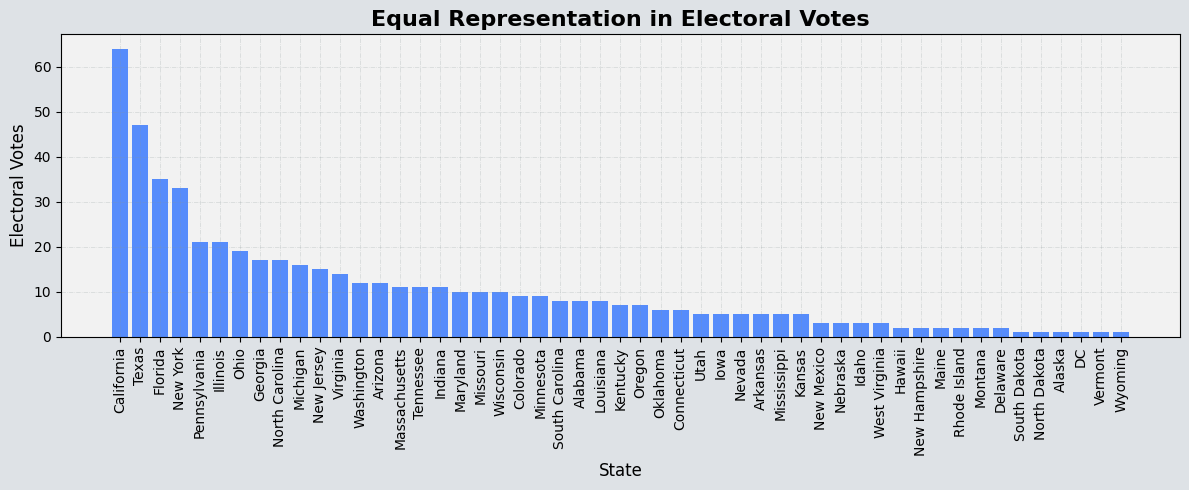

In [12]:
# visualization of equalized voting power

# define variables for axes
x1 = pop_data["state"]
y1 = pop_data["elect_votes_by_percent"]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

plt.ticklabel_format(axis='y', style='plain')
plt.bar(x1, y1)
ax.set_xticks(range(51))

ax.set_xticks(range(51))
ax.set_xticklabels(x1, rotation=90, ha="center")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Electoral Votes", fontsize=12)
ax.set_title("Equal Representation in Electoral Votes", fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

plt.tight_layout()
plt.show()

Let's say we take the lowest population of a state (Wyoming) and use that number to determine how many electoral college votes there should be for the United States.

In [13]:
state_min = pop_data["2020_census"].min()

new_vote_cnt = round(total_pop / state_min, 0)
print(f"The updated number of votes would be: {new_vote_cnt}.")
print(f"This increases the number of votes by {round(new_vote_cnt - total_votes, 0)}.")


The updated number of votes would be: 575.0.
This increases the number of votes by 37.0.


In [14]:
# add column for new vote count based on minimum population of a state (this means Wyoming is guaranteed at least one vote)

pop_data["new_vote_by_min_pop"] = round(pop_data["percent_of_total"] * new_vote_cnt, 0)
pop_data.head()

,Unnamed: 0,rank,state,state_code,2020_census,percent_of_total,elect_votes_by_percent,new_vote_by_min_pop
0,0,1,California,CA,39538223,0.1193,64.0,69.0
1,1,2,Texas,TX,29145505,0.0879,47.0,51.0
2,2,3,Florida,FL,21538187,0.0650,35.0,37.0
3,3,4,New York,NY,20201249,0.0609,33.0,35.0
4,4,5,Pennsylvania,PA,13002700,0.0392,21.0,23.0
5,5,6,Illinois,IL,12812508,0.0387,21.0,22.0
6,6,7,Ohio,OH,11799448,0.0356,19.0,20.0
7,7,8,Georgia,GA,10711908,0.0323,17.0,19.0
8,8,9,North Carolina,NC,10439388,0.0315,17.0,18.0
9,9,10,Michigan,MI,10077331,0.0304,16.0,17.0


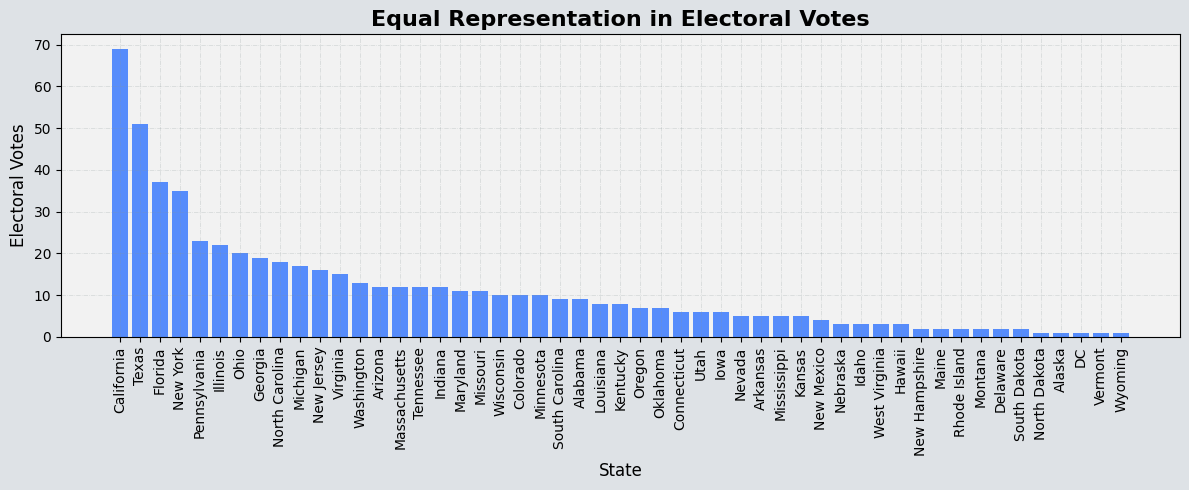

In [15]:
# visualization of equalized voting power using least populous state to represent the number of people per elector

# define variables for axes
x1 = pop_data["state"]
y1 = pop_data["new_vote_by_min_pop"]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

plt.ticklabel_format(axis='y', style='plain')
plt.bar(x1, y1)

ax.set_xticks(range(51))
ax.set_xticklabels(x1, rotation=90, ha="center")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Electoral Votes", fontsize=12)
ax.set_title("Equal Representation in Electoral Votes", fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

plt.tight_layout()
plt.show()

This looks much closer to the population spread, because the votes would be equally distributed. The current system uses a minimum of 3 electoral votes for certain groups. This is where most of the distortion comes from. Wyoming, the least populous states, gets three votes in the current system, but that really means they have 3 times the voting power of the most populous state, California. Although this graph looks quite skewed, it represents more closely how people are distributed in the United States.

In [16]:
# save table with population and electoral data as csv for further analysis
pop_data.to_csv("data/electoral_population_data.csv", index=False)
electoral_24.to_csv("data/electoral_24_data.csv", index=False)